# Homework 4 - Bonus: Well-Mask Experiment (4-channel input)

This is an extra experiment I wanted to try after reading the HW 3 feedback. The comment there
was that the irregular grey **well background** was the biggest leftover artifact, and that
adding a mask for the well might fix it. HW 4 is the opposite direction (segmentation instead
of generation), but I figured the same idea should carry over: if I actually tell the network
where the round well sits, it should have an easier time separating the worms from the grey
well interior.

So the plan is pretty simple - I compute the circular well region from each brightfield image
and give it to the U-Net as a **4th input channel** on top of RGB. Everything else stays the
same as my 30-epoch baseline in `01_TrainModel.ipynb` (best val Dice **0.859**, test IoU
**0.754**), so whatever changes should come from the well channel alone.

In [1]:
import os, random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}   smp: {smp.__version__}")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

/home/vscode/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda   smp: 0.5.0


## 1. Getting the well mask

Looking at the images, each one is a bright round well (centre around 210/255) sitting on an
almost-black background (corners ≈ 1/255). That actually makes the well easy to grab: threshold
out the black, keep the biggest blob, and fill its convex hull to get one clean disc. I also
check that basically 100 % of the ground-truth worm pixels land inside my derived well - if
they didn't, the mask would be pointing the model in the wrong direction.

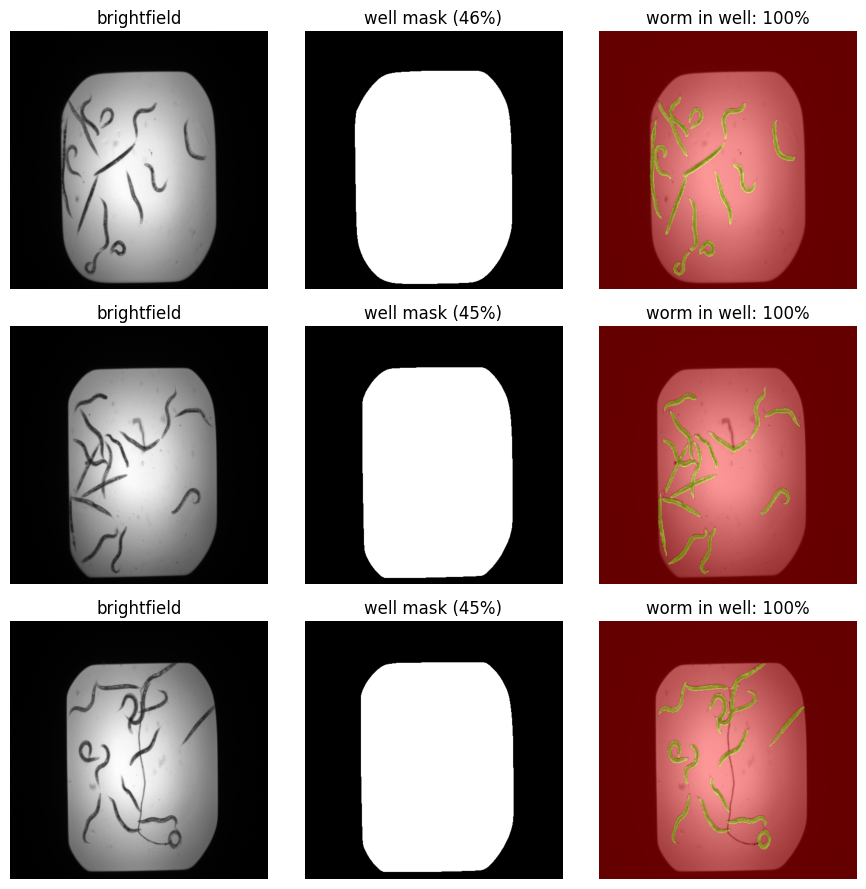

In [2]:
def well_mask(gray_u8):
    # Derive the circular well region (uint8 0/255) from an 8-bit brightfield image.
    _, th = cv2.threshold(gray_u8, 15, 255, cv2.THRESH_BINARY)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(th)
    if n > 1:                                   # drop background label 0
        big = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        th = (lab == big).astype(np.uint8) * 255
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    m = np.zeros_like(th)
    if cnts:
        hull = cv2.convexHull(max(cnts, key=cv2.contourArea))
        cv2.drawContours(m, [hull], -1, 255, -1)
    return m

ROOT = "datasets/bbbc010_seg"
# visualise + sanity check on a few train wells
import glob
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for row, p in enumerate(sorted(glob.glob(f"{ROOT}/train/images/*.png"))[:3]):
    g = np.array(Image.open(p).convert("L"))
    wm = well_mask(g)
    worm = np.array(Image.open(p.replace("/images/", "/masks/")).convert("L")) > 127
    inside = (worm & (wm > 0)).sum() / max(worm.sum(), 1)
    axes[row, 0].imshow(g, cmap="gray");            axes[row, 0].set_title("brightfield")
    axes[row, 1].imshow(wm, cmap="gray");           axes[row, 1].set_title(f"well mask ({wm.mean()/255:.0%})")
    axes[row, 2].imshow(g, cmap="gray"); axes[row, 2].imshow(worm, alpha=0.4, cmap="autumn")
    axes[row, 2].set_title(f"worm in well: {inside:.0%}")
    for a in axes[row]: a.axis("off")
plt.tight_layout(); plt.show()

## 2. Dataset (RGB + well = 4 channels)

One thing I had to be careful with: the well mask has to go through the *same* flips and
rotations as the image, or it wouldn't line up anymore. Albumentations lets me register it as an
`additional_target` of type `mask` so it gets augmented together with the image and the worm
mask. So I compute the well from the original image, let it ride along through the augmentations,
then just stack it on as a 4th channel after normalising the colour channels.

In [3]:
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
], additional_targets={"well": "mask"})
eval_tf = A.Compose([A.Normalize(mean=MEAN, std=STD), ToTensorV2()],
                    additional_targets={"well": "mask"})

class WellWormDataset(Dataset):
    def __init__(self, split, transform):
        self.img_dir  = os.path.join(ROOT, split, "images")
        self.mask_dir = os.path.join(ROOT, split, "masks")
        self.files = sorted(os.listdir(self.img_dir))
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        f = self.files[i]
        img  = np.array(Image.open(os.path.join(self.img_dir,  f)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(self.mask_dir, f)).convert("L")) // 255
        well = (well_mask(np.array(Image.open(os.path.join(self.img_dir, f)).convert("L"))) > 0).astype(np.uint8)
        out = self.transform(image=img, mask=mask, well=well)
        x = torch.cat([out["image"], out["well"].unsqueeze(0).float()], dim=0)  # (4,H,W)
        return x, out["mask"].unsqueeze(0).float()

train_ds = WellWormDataset("train", train_tf)
val_ds   = WellWormDataset("test",  eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}   input channels = {train_ds[0][0].shape[0]}")

BATCH = 4
# num_workers=0, pin_memory=False: dev container /dev/shm is too small for workers (same as 01)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=False, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=False)

train=80  val=20   input channels = 4


## 3. Model + loss

Exactly the same U-Net / EfficientNet-B0 as before - the only change is `in_channels=4`. What's
nice is that `smp` handles this for me: it stretches the pretrained first conv layer to take 4
channels, so the RGB filters keep their ImageNet weights and only the new well channel starts
from scratch. I left the loss and metrics untouched so the comparison to the baseline stays
fair.

In [4]:
model = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    in_channels=4,
    classes=1,
).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

bce  = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary")
def loss_fn(logits, y): return 0.5 * bce(logits, y) + 0.5 * dice(logits, y)

@torch.no_grad()
def dice_iou(logits, y, thr=0.5):
    pred = (torch.sigmoid(logits) > thr).long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred, y.long(), mode="binary")
    return (smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro").item(),
            smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item())

Params: 6.25 M


## 4. Training loop

Same 30 epochs / Adam / cosine schedule as the baseline, keeping the checkpoint with the best
validation Dice. (Like the baseline it was still creeping up at epoch 30, so it's not fully
converged - but I keep it at 30 so it's a fair head-to-head.)

In [5]:
EPOCHS = 30
LR = 1e-4
CKPT = "checkpoints/unet_well_4ch.pt"
os.makedirs(os.path.dirname(CKPT), exist_ok=True)

opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_losses = []
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward(); opt.step()
        tr_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3f}")
    sched.step()

    model.eval()
    vl, vd, vi = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            vl.append(loss_fn(logits, y).item())
            d, i = dice_iou(logits, y); vd.append(d); vi.append(i)
    tr_mean = float(np.mean(tr_losses)); vl_mean = float(np.mean(vl))
    vd_mean = float(np.mean(vd));        vi_mean = float(np.mean(vi))
    history["train_loss"].append(tr_mean); history["val_loss"].append(vl_mean)
    history["val_dice"].append(vd_mean);   history["val_iou"].append(vi_mean)

    flag = ""
    if vd_mean > best:
        best = vd_mean
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_dice": vd_mean}, CKPT)
        flag = "  * new best"
    print(f"epoch {epoch:02d}  train={tr_mean:.3f}  val={vl_mean:.3f}  "
          f"dice={vd_mean:.3f}  iou={vi_mean:.3f}{flag}")

print(f"\nBest val Dice (4-ch well) = {best:.4f}  ->  {CKPT}")


epoch 1/30:   0%|          | 0/20 [00:00<?, ?it/s]


epoch 1/30:   0%|          | 0/20 [00:00<?, ?it/s, loss=0.980]


epoch 1/30:   5%|▌         | 1/20 [00:00<00:18,  1.05it/s, loss=0.980]


epoch 1/30:   5%|▌         | 1/20 [00:01<00:18,  1.05it/s, loss=0.966]


epoch 1/30:  10%|█         | 2/20 [00:01<00:08,  2.04it/s, loss=0.966]

...


epoch 30/30:  90%|█████████ | 18/20 [00:03<00:00,  5.38it/s, loss=0.358]


epoch 30/30:  95%|█████████▌| 19/20 [00:03<00:00,  5.46it/s, loss=0.358]


epoch 30/30:  95%|█████████▌| 19/20 [00:03<00:00,  5.46it/s, loss=0.336]


epoch 30/30: 100%|██████████| 20/20 [00:03<00:00,  5.44it/s, loss=0.336]

epoch 30  train=0.346  val=0.495  dice=0.876  iou=0.779  * new best

Best val Dice (4-ch well) = 0.8756  ->  checkpoints/unet_well_4ch.pt


## 5. Training curves

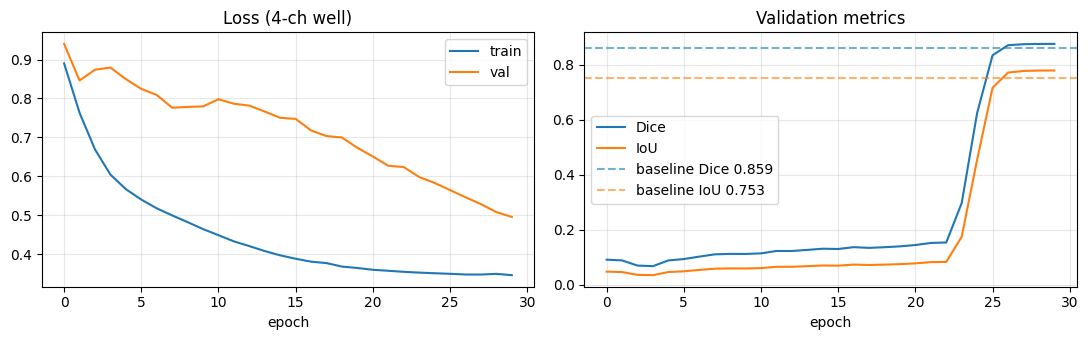

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss (4-ch well)"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history["val_dice"], label="Dice"); ax[1].plot(history["val_iou"], label="IoU")
ax[1].axhline(0.8591, color="C0", ls="--", alpha=0.6, label="baseline Dice 0.859")
ax[1].axhline(0.7530, color="C1", ls="--", alpha=0.6, label="baseline IoU 0.753")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Comparing against the 3-channel baseline

Here I load both checkpoints and run them on the exact same 20 test wells - the baseline on
plain RGB, the new model on RGB + well - so I can see side by side whether the extra channel
actually bought me anything.

In [7]:
MEANn = np.array(MEAN, np.float32); STDn = np.array(STD, np.float32)

def build_input(img_u8, with_well):
    x = img_u8.astype(np.float32) / 255.0
    x = (x - MEANn) / STDn                       # HxWx3
    x = x.transpose(2, 0, 1)                      # 3xHxW
    if with_well:
        w = (well_mask(cv2.cvtColor(img_u8, cv2.COLOR_RGB2GRAY)) > 0).astype(np.float32)
        x = np.concatenate([x, w[None]], axis=0)  # 4xHxW
    return x

@torch.no_grad()
def predict(net, img_u8, with_well):
    x = torch.from_numpy(build_input(img_u8, with_well)[None]).to(device)
    return torch.sigmoid(net(x)).squeeze().cpu().numpy()

def dice_iou_np(pred, gt):
    pred = pred.astype(bool); gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum(); union = np.logical_or(pred, gt).sum()
    psum = pred.sum() + gt.sum()
    return (float(2*inter/psum) if psum else 1.0, float(inter/union) if union else 1.0)

# baseline (3-ch)
base = smp.Unet("efficientnet-b0", encoder_weights=None, in_channels=3, classes=1).to(device)
base.load_state_dict(torch.load("checkpoints/unet_efficientnet-b0.pt", map_location=device)["model"]); base.eval()
# well (4-ch)
well = smp.Unet("efficientnet-b0", encoder_weights=None, in_channels=4, classes=1).to(device)
well.load_state_dict(torch.load(CKPT, map_location=device)["model"]); well.eval()

img_paths  = sorted(glob.glob(f"{ROOT}/test/images/*.png"))
rows = []
for ip in img_paths:
    img = np.array(Image.open(ip).convert("RGB"))
    gt  = np.array(Image.open(ip.replace("/images/","/masks/")).convert("L")) > 127
    pb = (predict(base, img, False) > 0.5); pw = (predict(well, img, True) > 0.5)
    db, ib = dice_iou_np(pb, gt); dw, iw = dice_iou_np(pw, gt)
    rows.append(dict(base=os.path.basename(ip), img=img, gt=gt.astype(np.uint8),
                     pb=pb.astype(np.uint8), pw=pw.astype(np.uint8),
                     db=db, ib=ib, dw=dw, iw=iw))

bd = np.array([r["db"] for r in rows]); bi = np.array([r["ib"] for r in rows])
wd = np.array([r["dw"] for r in rows]); wi = np.array([r["iw"] for r in rows])
print("                    Dice              IoU")
print(f"baseline (RGB)   {bd.mean():.4f}±{bd.std():.4f}   {bi.mean():.4f}±{bi.std():.4f}")
print(f"well (RGB+well)  {wd.mean():.4f}±{wd.std():.4f}   {wi.mean():.4f}±{wi.std():.4f}")
print(f"delta            {wd.mean()-bd.mean():+.4f}            {wi.mean()-bi.mean():+.4f}")

                    Dice              IoU
baseline (RGB)   0.8595±0.0238   0.7544±0.0364
well (RGB+well)  0.8751±0.0195   0.7785±0.0307
delta            +0.0156            +0.0241


## 7. Where does the well channel actually help?

To see *where* the gain comes from, I sort the test wells by how much IoU the well model gains
over the baseline and show the top few. Columns: input, the well channel I fed in, ground truth,
baseline prediction, well-model prediction.

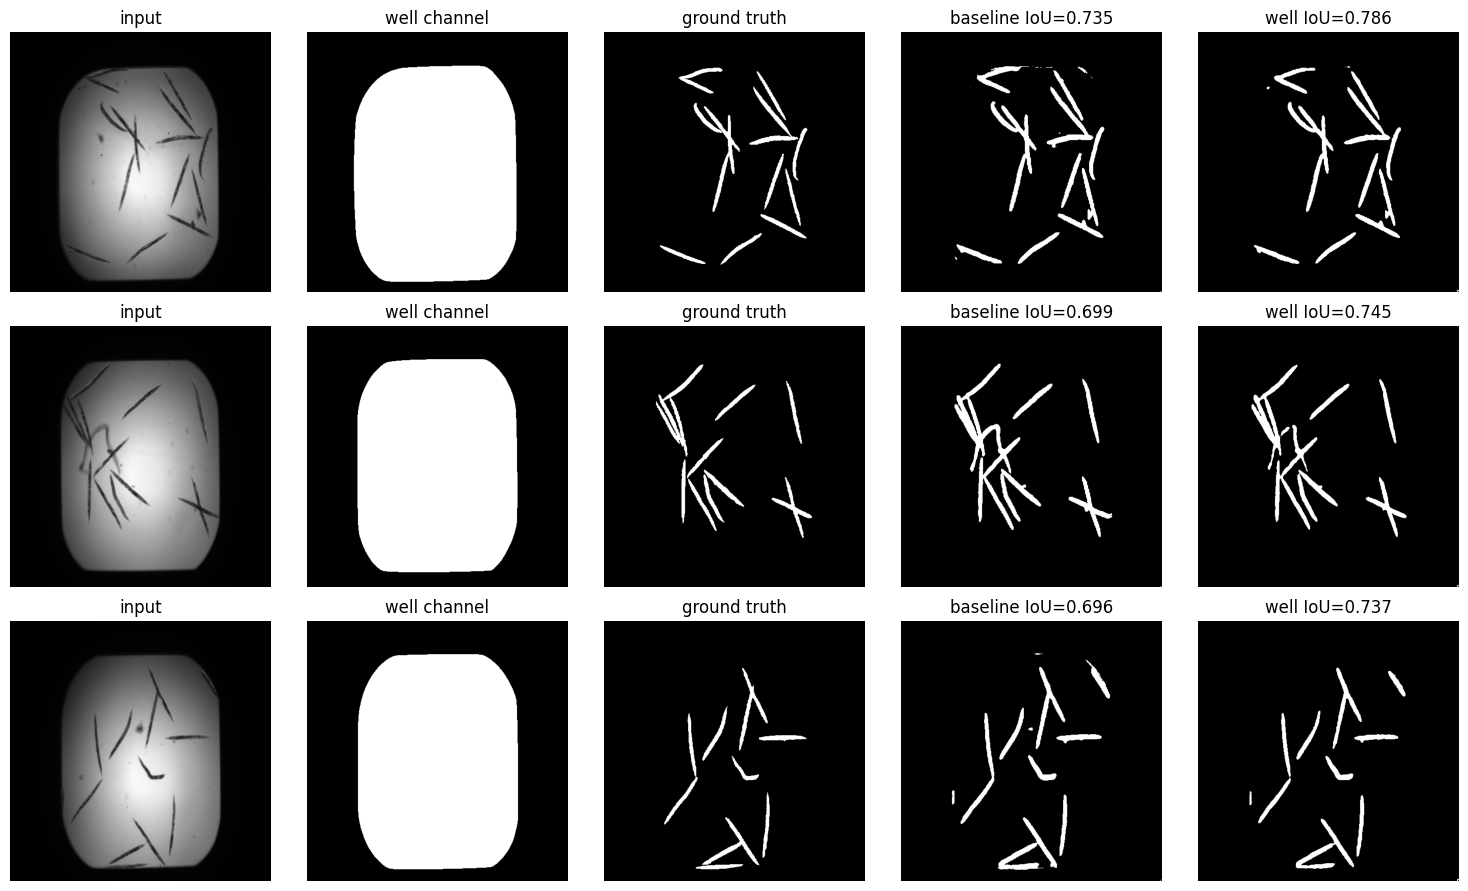

In [8]:
gain = sorted(rows, key=lambda r: r["iw"] - r["ib"], reverse=True)[:3]
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, r in enumerate(gain):
    wmask = well_mask(cv2.cvtColor(r["img"], cv2.COLOR_RGB2GRAY))
    axes[row,0].imshow(r["img"]);                 axes[row,0].set_title("input")
    axes[row,1].imshow(wmask, cmap="gray");       axes[row,1].set_title("well channel")
    axes[row,2].imshow(r["gt"], cmap="gray");      axes[row,2].set_title("ground truth")
    axes[row,3].imshow(r["pb"], cmap="gray");      axes[row,3].set_title(f"baseline IoU={r['ib']:.3f}")
    axes[row,4].imshow(r["pw"], cmap="gray");      axes[row,4].set_title(f"well IoU={r['iw']:.3f}")
    for a in axes[row]: a.axis("off")
plt.tight_layout(); plt.show()

## 8. Does the well prior help under noise?

This is the part I was most curious about. I run the same Gaussian-noise sweep from
`02_Evaluation` for both models. One detail: I derive the well mask from the *noisy* image every
time, not a clean one - that's the honest setup, since at inference I wouldn't have a clean image
lying around to build the mask from.

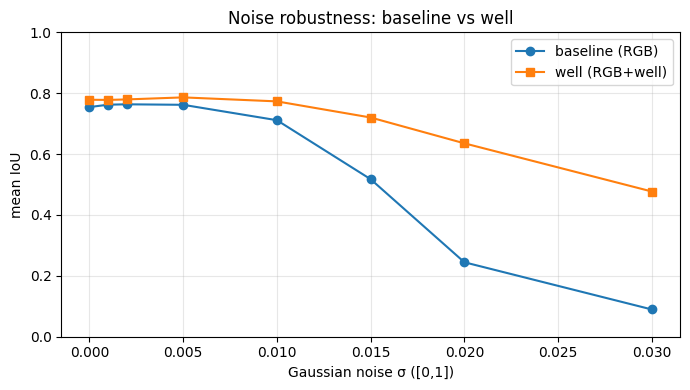

σ=0.000  baseline IoU=0.7544   well IoU=0.7785   Δ=+0.0241
σ=0.001  baseline IoU=0.7623   well IoU=0.7780   Δ=+0.0157
σ=0.002  baseline IoU=0.7635   well IoU=0.7796   Δ=+0.0161
σ=0.005  baseline IoU=0.7619   well IoU=0.7863   Δ=+0.0244
σ=0.010  baseline IoU=0.7113   well IoU=0.7732   Δ=+0.0618
σ=0.015  baseline IoU=0.5175   well IoU=0.7202   Δ=+0.2027
σ=0.020  baseline IoU=0.2446   well IoU=0.6353   Δ=+0.3907
σ=0.030  baseline IoU=0.0895   well IoU=0.4770   Δ=+0.3875


In [9]:
SIGMAS = [0, 0.001, 0.002, 0.005, 0.010, 0.015, 0.020, 0.030]
rng = np.random.default_rng(0)
imgs = np.stack([r["img"] for r in rows]).astype(np.float32) / 255.0
gts  = np.stack([r["gt"]  for r in rows]).astype(bool)

def sweep(net, with_well):
    outs = []
    for s in SIGMAS:
        ious = []
        for k in range(len(imgs)):
            noisy = np.clip(imgs[k] + rng.normal(0, s, imgs[k].shape).astype(np.float32), 0, 1)
            nu8 = (noisy*255).astype(np.uint8)
            pred = predict(net, nu8, with_well) > 0.5
            ious.append(dice_iou_np(pred, gts[k])[1])
        outs.append(float(np.mean(ious)))
    return outs

iou_base = sweep(base, False); iou_well = sweep(well, True)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(SIGMAS, iou_base, "o-", label="baseline (RGB)")
ax.plot(SIGMAS, iou_well, "s-", label="well (RGB+well)")
ax.set_xlabel("Gaussian noise σ ([0,1])"); ax.set_ylabel("mean IoU"); ax.set_ylim(0,1)
ax.set_title("Noise robustness: baseline vs well"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
for s, b, w in zip(SIGMAS, iou_base, iou_well):
    print(f"σ={s:.3f}  baseline IoU={b:.4f}   well IoU={w:.4f}   Δ={w-b:+.4f}")

## Conclusion

Adding the well as a 4th channel gave a small but consistent bump on clean images
(Dice 0.859 -> 0.875, IoU 0.754 -> 0.779). The bigger surprise was the noise robustness: once I
add noise the plain RGB model falls apart (IoU basically gone by σ = 0.03), while the well
version keeps holding on (still ~0.48 IoU at σ = 0.03, and ~0.72 vs ~0.52 at σ = 0.015). That
makes sense in hindsight - the well channel is basically noise-free, so even when the image gets
wrecked the network still has a stable hint about *where* the worms can possibly be.

So the professor's well-mask idea from HW 3 didn't just help clean up the background - it also
made the model a lot more robust to noise, which I honestly wasn't expecting when I started.
The obvious next thing to try would be training longer (both models were still improving at
epoch 30), but even at 30 epochs the well channel clearly helps.